<a href="https://colab.research.google.com/github/dmorganc14/Proyecto-Telecom-X/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Telecom X - Análisis de Evasión de Clientes (Churn)

## 📌 Introducción

Telecom X enfrenta una alta tasa de cancelación de clientes (Churn).  
El objetivo de este proyecto es analizar los datos de clientes para identificar patrones y factores que influyen en la evasión del servicio.

A través de este análisis realizaremos:

- Extracción de datos desde una API en formato JSON
- Limpieza y transformación de datos (ETL)
- Análisis exploratorio de datos (EDA)
- Visualización de patrones relevantes
- Generación de insights estratégicos

Este análisis permitirá al equipo de Data Science desarrollar modelos predictivos que ayuden a reducir la pérdida de clientes.

#📌 Extracción

In [44]:
# ==========================================================
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================================

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Lectura de datos desde API
import requests

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# ==========================================================
# EXTRACCIÓN DE DATOS DESDE API (JSON)
# ==========================================================

# URL del dataset
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# Solicitud a la API
response = requests.get(url)

# Convertimos a formato JSON
data = response.json()

print("Datos cargados correctamente desde la API")

Datos cargados correctamente desde la API


#🔧 Transformación

Antes de realizar el análisis de los datos, es fundamental comprender el significado de cada variable presente en el conjunto de datos. Para ello se utiliza el diccionario de datos, el cual describe las características de cada campo incluido en el dataset.

El diccionario original del proyecto puede consultarse en el siguiente enlace:

Diccionario de datos TelecomX:
https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_diccionario.md

Sin embargo, para facilitar la interpretación del dataset durante el análisis, a continuación se presenta una tabla resumen de las variables más relevantes incluidas en el conjunto de datos.

In [45]:
# Crear diccionario con las variables y su descripción
diccionario_datos = {
    "Variable": [
        "customerID", "Churn", "gender", "SeniorCitizen", "Partner",
        "Dependents", "tenure", "PhoneService", "MultipleLines",
        "InternetService", "OnlineSecurity", "OnlineBackup",
        "DeviceProtection", "TechSupport", "StreamingTV",
        "StreamingMovies", "Contract", "PaperlessBilling",
        "PaymentMethod", "MonthlyCharges", "TotalCharges"
    ],

    "Descripción": [
        "Identificador único del cliente",
        "Indica si el cliente canceló el servicio",
        "Género del cliente",
        "Indica si el cliente es adulto mayor",
        "Indica si el cliente tiene pareja",
        "Indica si el cliente tiene dependientes",
        "Tiempo que el cliente ha permanecido en la empresa (meses)",
        "Indica si el cliente tiene servicio telefónico",
        "Indica si el cliente tiene múltiples líneas telefónicas",
        "Tipo de servicio de internet contratado",
        "Indica si el cliente tiene seguridad en línea",
        "Indica si el cliente tiene respaldo en línea",
        "Indica si el cliente tiene protección de dispositivos",
        "Indica si el cliente tiene soporte técnico",
        "Indica si el cliente tiene streaming de TV",
        "Indica si el cliente tiene streaming de películas",
        "Tipo de contrato del cliente",
        "Indica si usa facturación electrónica",
        "Método de pago del cliente",
        "Cargo mensual del servicio",
        "Total pagado por el cliente"
    ]
}

# Convertir a DataFrame
df_diccionario = pd.DataFrame(diccionario_datos)

df_diccionario.style.set_properties(**{
    'text-align': 'left'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left')]}
])

# Mostrar tabla
df_diccionario

,Variable,Descripción
0,customerID,Identificador único del cliente
1,Churn,Indica si el cliente canceló el servicio
2,gender,Género del cliente
3,SeniorCitizen,Indica si el cliente es adulto mayor
4,Partner,Indica si el cliente tiene pareja
5,Dependents,Indica si el cliente tiene dependientes
6,tenure,Tiempo que el cliente ha permanecido en la emp...
7,PhoneService,Indica si el cliente tiene servicio telefónico
8,MultipleLines,Indica si el cliente tiene múltiples líneas te...
9,InternetService,Tipo de servicio de internet contratado


In [46]:
# ==========================================================
# TRANSFORMACIÓN DE LOS DATOS
# ==========================================================

# Convertimos el JSON a DataFrame
df = pd.json_normalize(data)

# Mostramos las primeras filas
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


Entendiendo los datos

In [47]:
# ==========================================================
# EXPLORACIÓN INICIAL DEL DATASET
# ==========================================================

# Dimensiones del dataset
print("Filas y columnas del dataset:")
print(df.shape)

# Tipos de datos
print("\nTipos de datos:")
print(df.dtypes)

# Nombres de columnas
print("\nColumnas disponibles:")
print(df.columns)

Filas y columnas del dataset:
(7267, 21)

Tipos de datos:
customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneService            object
phone.MultipleLines           object
internet.InternetService      object
internet.OnlineSecurity       object
internet.OnlineBackup         object
internet.DeviceProtection     object
internet.TechSupport          object
internet.StreamingTV          object
internet.StreamingMovies      object
account.Contract              object
account.PaperlessBilling      object
account.PaymentMethod         object
account.Charges.Monthly      float64
account.Charges.Total         object
dtype: object

Columnas disponibles:
Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'cu

In [48]:
# ==========================================================
# LIMPIEZA DE DATOS
# ==========================================================

# Eliminamos duplicados si existen
df.drop_duplicates(inplace=True)

# Revisamos valores nulos
print("Valores nulos por columna:\n")
print(df.isnull().sum())

Valores nulos por columna:

customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


In [49]:
# ==========================================================
# TRANSFORMACIÓN DE VARIABLES
# ==========================================================

# Convertimos Churn a variable binaria
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

# Convertimos TotalCharges a numérico
df["account.Charges.Total"] = pd.to_numeric(df["account.Charges.Total"], errors="coerce")

# Eliminamos nulos si existen
df.dropna(inplace=True)

print("Transformación completada")

Transformación completada


#📊 Carga y análisis

##Distribución del Churn

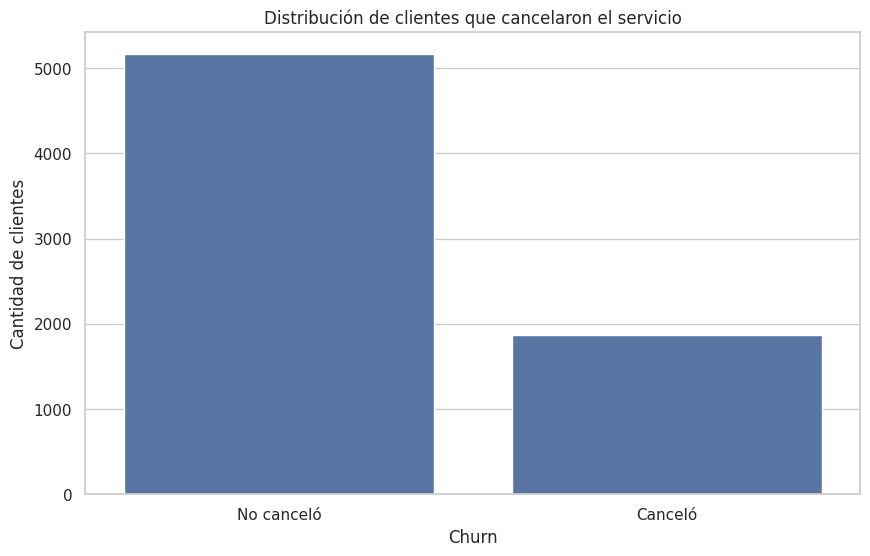

In [50]:
# ==========================================================
# DISTRIBUCIÓN DE CLIENTES QUE CANCELARON
# ==========================================================

sns.countplot(x="Churn", data=df)

plt.title("Distribución de clientes que cancelaron el servicio")
plt.xticks([0,1], ["No canceló","Canceló"])
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")

plt.show()

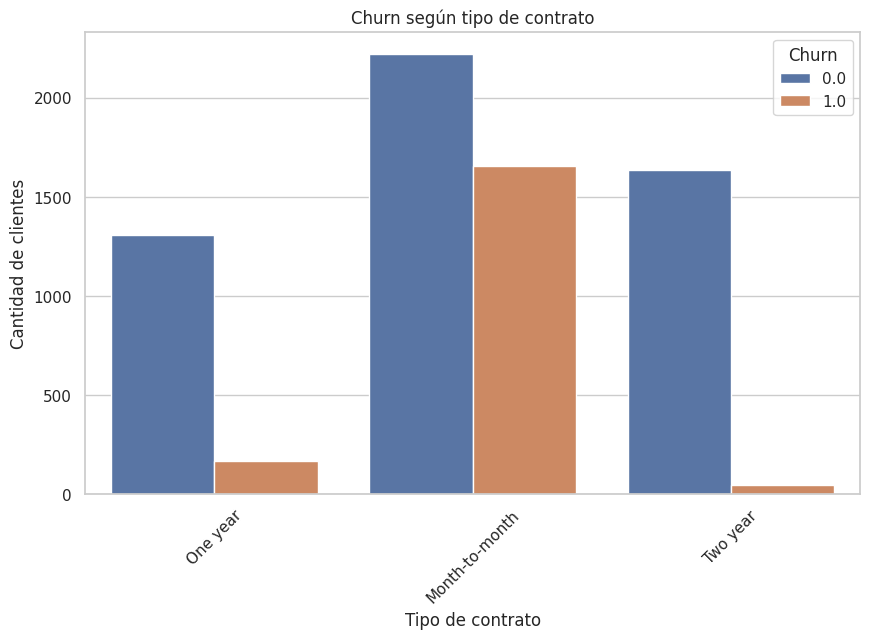

In [51]:
# ==========================================================
# RELACIÓN ENTRE CONTRATO Y CANCELACIÓN
# ==========================================================

sns.countplot(data=df, x="account.Contract", hue="Churn")

plt.title("Churn según tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=45)

plt.show()

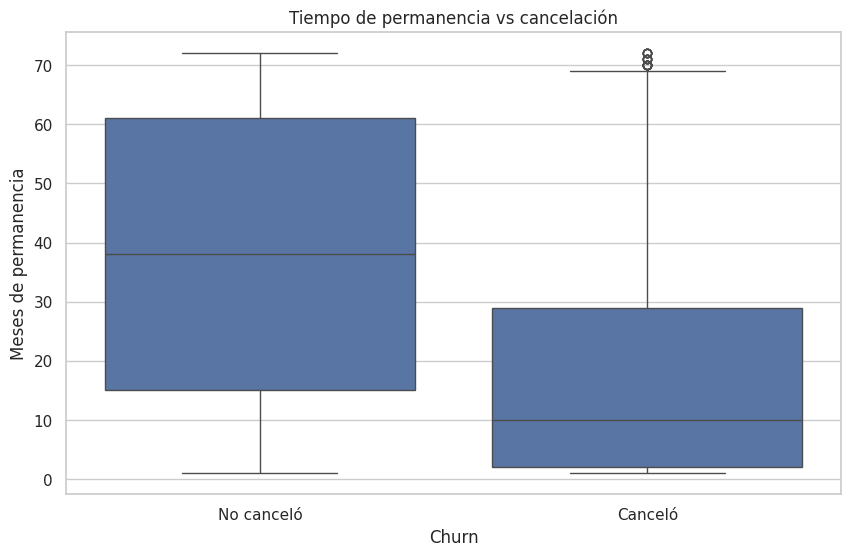

In [52]:
# ==========================================================
# 9. TENURE VS CHURN
# ==========================================================

sns.boxplot(x="Churn", y="customer.tenure", data=df)

plt.title("Tiempo de permanencia vs cancelación")
plt.xticks([0,1],["No canceló","Canceló"])
plt.xlabel("Churn")
plt.ylabel("Meses de permanencia")

plt.show()

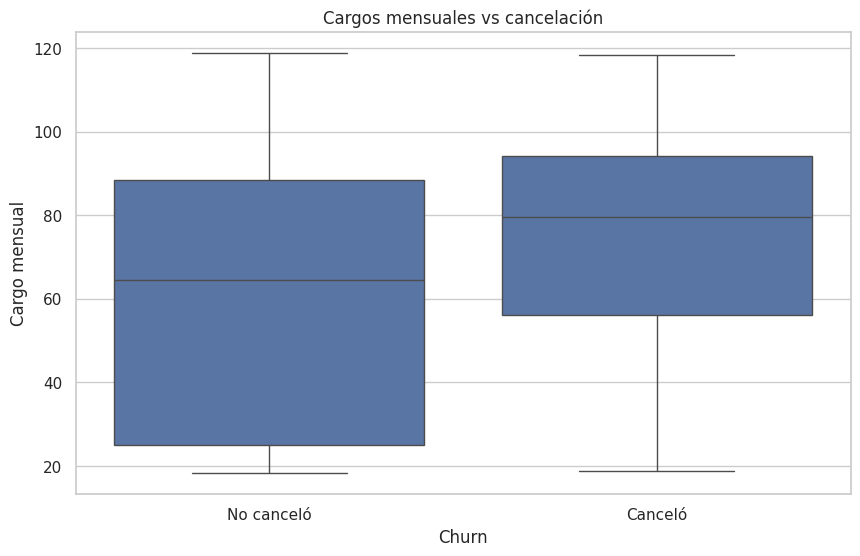

In [53]:
# ==========================================================
# CARGOS MENSUALES VS CHURN
# ==========================================================

sns.boxplot(x="Churn", y="account.Charges.Monthly", data=df)

plt.title("Cargos mensuales vs cancelación")
plt.xticks([0,1],["No canceló","Canceló"])
plt.xlabel("Churn")
plt.ylabel("Cargo mensual")

plt.show()

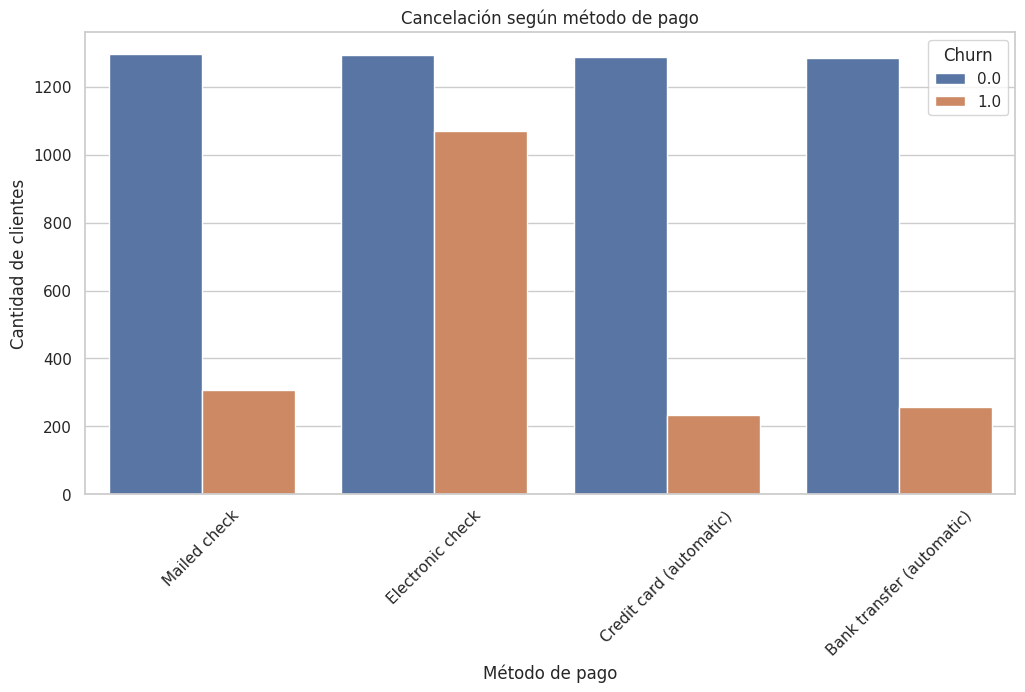

In [54]:
# ==========================================================
# MÉTODO DE PAGO Y CANCELACIÓN
# ==========================================================

plt.figure(figsize=(12,6))

sns.countplot(data=df, x="account.PaymentMethod", hue="Churn")

plt.title("Cancelación según método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=45)

plt.show()

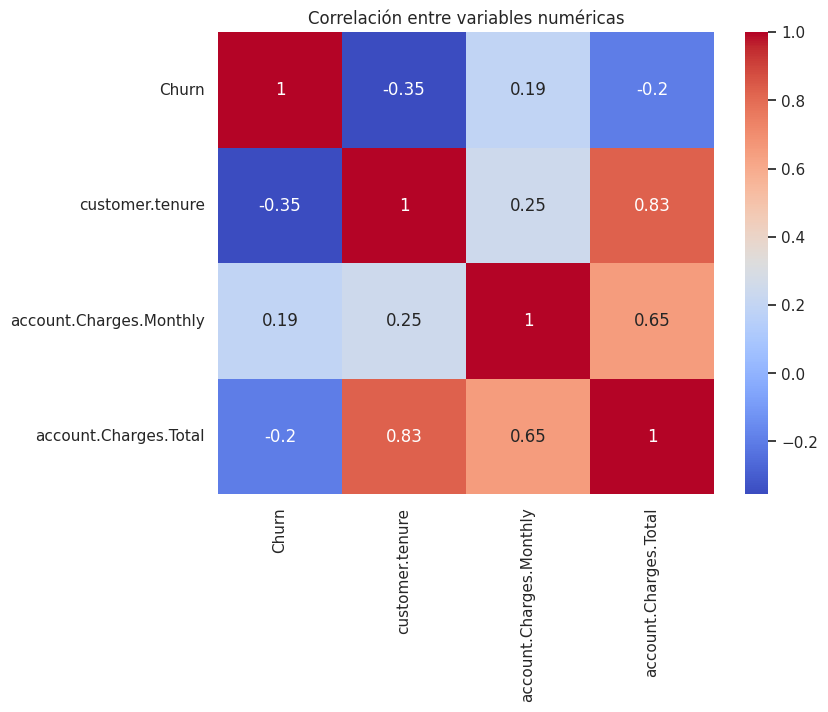

In [55]:
# ==========================================================
# MATRIZ DE CORRELACIÓN
# ==========================================================

plt.figure(figsize=(8,6))

correlacion = df[[
    "Churn",
    "customer.tenure",
    "account.Charges.Monthly",
    "account.Charges.Total"
]].corr()

sns.heatmap(correlacion, annot=True, cmap="coolwarm")

plt.title("Correlación entre variables numéricas")

plt.show()

#📄Informe final

# 📊 Conclusiones del Análisis

Después de realizar el análisis exploratorio se identificaron varios factores asociados a la cancelación del servicio.

## 🔎 Hallazgos principales

**1️⃣ Tipo de contrato**
- Los clientes con contratos mensuales presentan una mayor tasa de cancelación.
- Los contratos de largo plazo muestran mayor retención.

**2️⃣ Tiempo de permanencia**
- Los clientes que cancelan suelen tener menor tiempo en la empresa.

**3️⃣ Cargos mensuales**
- Los clientes con cargos mensuales más altos presentan mayor probabilidad de churn.

**4️⃣ Método de pago**
- Algunos métodos de pago presentan mayor proporción de cancelaciones.

## 📈 Recomendaciones para Telecom X

- Ofrecer incentivos para migrar clientes a contratos de largo plazo.
- Implementar estrategias de fidelización durante los primeros meses.
- Analizar planes de precios para clientes con cargos mensuales elevados.
- Diseñar promociones específicas para clientes con mayor riesgo de cancelación.

Este análisis proporciona información valiosa que puede ser utilizada para construir modelos predictivos de churn y desarrollar estrategias para mejorar la retención de clientes.